# 06. Time Series Forecasting

## What You'll Learn
In this notebook you will
- Build `TimeSeries` objects from data
- Build TimeSeries models   
    - AR(p)
    - MA(q)
    - ARIMA(p,d,q)
    - ARIMAX(p,d,q,b)
- Use Bayesian methods
- Validate this TimeSeries models
## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from RMC.BestFit.Models import ARIMAX, AutoRegressive, MovingAverage, ARIMA, Transform
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod
from RMC.BestFit.Analyses import ARAnalysis, MAAnalysis, ARIMAAnalysis, ARIMAXAnalysis

from Numerics.Data import TimeSeries, TimeInterval
from Numerics.Data.Statistics import Autocorrelation, Statistics, HypothesisTests
from Numerics.Distributions import ChiSquared

from System import DateTime, Double
from System.Collections.Generic import List

Time series analysis is the statistical study of data points collected sequentially over time. Unlike cross-sectional data where observations are assumed independent, time series data exhibit temporal dependence — today's observation is related to yesterday's, and tomorrow's will be related to today's. Understanding and modeling this dependence is essential for forecasting future values and understanding the dynamics of the system being studied.

## Why Time Series Analysis Matters

Consider a water resources engineer tasked with forecasting next month's streamflow for reservoir operations. Simply using the long-term average ignores valuable information: if this month's flow is unusually high, next month's flow is likely to also be above average (rivers don't jump randomly between extremes). Time series models capture this persistence, producing better forecasts than naive methods.

Time series analysis is fundamental to:

- **Streamflow forecasting**: Predict future flows for reservoir operations, water supply planning
- **Climate projections**: Model temperature, precipitation, and drought indices
- **Demand forecasting**: Predict water demand, electricity load, or economic variables
- **Quality control**: Detect anomalies in sensor data through residual monitoring
- **Understanding dynamics**: Quantify how quickly systems respond to perturbations

The ***RMC.BestFit*** library provides a comprehensive suite of time series models with both Maximum Likelihood (MLE) and Bayesian MCMC estimation, enabling full uncertainty quantification for forecasts.

## Core Concepts

Before diving into specific models, let's establish key concepts that underpin all time series analysis.

A time series is **stationary** if its statistical properties (mean, variance, autocorrelation structure) don't change over time. Most classical time series models assume stationarity because:

1. Non-stationary series have time-varying parameters, making estimation ill-defined
2. Forecasts from non-stationary models can diverge to infinity
3. Standard statistical tests assume stationarity

**Weak stationarity** (the practical definition) requires:
- Constant mean: $E[Y_t] = \mu$ for all $t$
- Constant variance: $\text{Var}(Y_t) = \sigma^2$ for all $t$
- Autocovariance depends only on lag: $\text{Cov}(Y_t, Y_{t+h}) = \gamma(h)$ for all $t$

Many real-world series are non-stationary due to trends or seasonality. The ARIMA framework handles this by differencing the series to achieve stationarity before modeling.

### Autocorrelation

**Autocorrelation** measures the correlation between a time series and lagged versions of itself. The autocorrelation function (ACF) at lag $h$ is:

```math
\rho(h) = \frac{\text{Cov}(Y_t, Y_{t+h})}{\text{Var}(Y_t)} = \frac{\gamma(h)}{\gamma(0)}
```

The ACF reveals the memory structure of the series:
- **Fast decay**: Short-memory process (AR models with small coefficients)
- **Slow decay**: Long-memory or near unit-root process
- **Sharp cutoff**: MA structure (ACF drops to zero after lag $q$)
- **Sinusoidal pattern**: Seasonal or cyclical component

The **partial autocorrelation function (PACF)** measures the correlation between $Y_t$ and $Y_{t+h}$ after removing the linear effect of intermediate lags $Y_{t+1}, \ldots, Y_{t+h-1}$. The PACF is crucial for identifying AR order:
- AR(p) process: PACF cuts off after lag $p$
- MA(q) process: PACF decays gradually

### White Noise

**White noise** is a sequence of uncorrelated random variables with constant mean and variance:

```math
\varepsilon_t \stackrel{iid}{\sim} N(0, \sigma^2)
```

White noise has:
- $\rho(0) = 1$ (correlation with itself)
- $\rho(h) = 0$ for $h \neq 0$ (no correlation at any lag)

The goal of time series modeling is to transform the observed series into white noise residuals. If residuals still show autocorrelation, the model is missing structure.

### The Backshift Operator

The **backshift (lag) operator** $L$ simplifies notation:

```math
L Y_t = Y_{t-1}, \quad L^2 Y_t = Y_{t-2}, \quad L^k Y_t = Y_{t-k}
```

The **difference operator** is:

```math
\Delta Y_t = Y_t - Y_{t-1} = (1 - L) Y_t
```

Higher-order differences:

```math
\Delta^2 Y_t = \Delta(\Delta Y_t) = Y_t - 2Y_{t-1} + Y_{t-2} = (1-L)^2 Y_t
```

Using these operators, model equations become compact polynomial expressions that reveal the mathematical structure.

## Model Overview

The ***RMC.BestFit*** library implements four primary time series model classes:

| Model | Class | Parameters | When to Use |
|-------|-------|------------|-------------|
| AR(p) | `AutoRegressive` | $p + 2$ | Gradual ACF decay, sharp PACF cutoff |
| MA(q) | `MovingAverage` | $q + 2$ | Sharp ACF cutoff, gradual PACF decay |
| ARIMA(p,d,q) | `ARIMA` | $p + q + 2$ | Non-stationary series needing differencing |
| ARIMAX(p,d,q,b) | `ARIMAX` | $p + q + K + 2+$ | External predictors available |

---

## Autoregressive Model — AR(p)

The autoregressive model is the workhorse of time series analysis. It expresses the current value as a linear combination of past values plus random noise — essentially a regression of the series on its own lagged values.

### Intuition

Imagine predicting tomorrow's river flow. If today's flow is high, tomorrow's is likely high too (persistence). If yesterday's was also high, that provides additional information. An AR model formalizes this: predict today using a weighted combination of recent past values.

The "order" $p$ specifies how many past values to include. An AR(1) uses only yesterday; AR(2) uses yesterday and the day before; and so on.

### Mathematical Formulation

The AR(p) model is defined as [[1]](#1):

```math
Y_t = \mu + \sum_{i=1}^{p} \phi_i (Y_{t-i} - \mu) + \varepsilon_t
```

where:
- $Y_t$ is the observation at time $t$
- $\mu$ is the process mean (intercept)
- $\phi_1, \phi_2, \ldots, \phi_p$ are the AR coefficients
- $\varepsilon_t \stackrel{iid}{\sim} N(0, \sigma^2)$ is white noise

An equivalent formulation that's often more intuitive:

```math
Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \ldots + \phi_p Y_{t-p} + \varepsilon_t
```

where $c = \mu(1 - \phi_1 - \phi_2 - \ldots - \phi_p)$ is a constant term.

Using the backshift operator:

```math
\Phi(L)(Y_t - \mu) = \varepsilon_t
```

where $\Phi(L) = 1 - \phi_1 L - \phi_2 L^2 - \ldots - \phi_p L^p$ is the **AR polynomial**.

### Parameters

For an AR(p) model with intercept:
- $\mu$: Process mean (intercept)
- $\phi_1, \phi_2, \ldots, \phi_p$: AR coefficients
- $\sigma$: Error standard deviation

**Total parameters:** $p + 2$ (with intercept) or $p + 1$ (without intercept)

### Stationarity Conditions

For a stationary AR process, all roots of the characteristic polynomial must lie **outside** the unit circle [[1]](#1):

```math
\Phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \ldots - \phi_p z^p = 0
```

This ensures the process doesn't explode to infinity.

**Simplified conditions for low orders:**
- **AR(1)**: $|\phi_1| < 1$
- **AR(2)**: $\phi_1 + \phi_2 < 1$, $\phi_2 - \phi_1 < 1$, $|\phi_2| < 1$

A sufficient (but not necessary) general condition: $\sum_{i=1}^{p} |\phi_i| < 1$

**Interpretation of coefficients:**
- $\phi_1 > 0$: Positive persistence (high values followed by high values)
- $\phi_1 < 0$: Oscillating behavior (high values followed by low values)
- $\phi_1 \approx 1$: Near unit root, very persistent (slow mean reversion)
- $\phi_1 \approx 0$: Little dependence on immediate past

### ACF and PACF Patterns

The AR(p) process has distinctive correlation patterns:

| Statistic | Pattern |
|-----------|---------|
| ACF | Exponential decay (or damped sinusoid for complex roots) |
| PACF | Cuts off sharply after lag $p$ |

This PACF cutoff is the key diagnostic for identifying AR order.

### Likelihood Function

The conditional log-likelihood, conditioning on the first $p$ observations, is [[2]](#2):

```math
\ell(\theta) = -\frac{n-p}{2}\log(2\pi) - (n-p)\log(\sigma) - \frac{1}{2\sigma^2}\sum_{t=p+1}^{n} \varepsilon_t^2
```

where the residuals are:

```math
\varepsilon_t = Y_t - \mu - \sum_{i=1}^{p} \phi_i (Y_{t-i} - \mu)
```

### Implementation Example
Let's fit an AR(2) model to monthly streamflow data

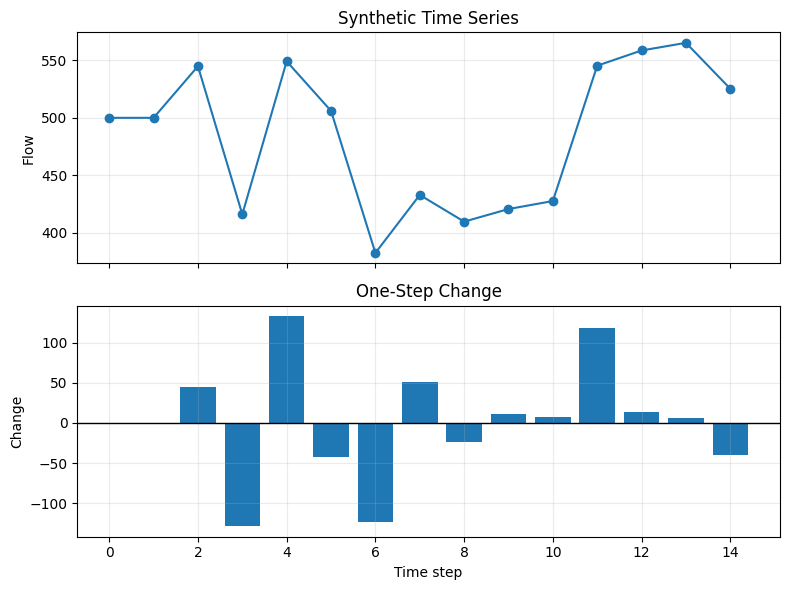

In [18]:
# Generate synthetic monthly flow data
rng = np.random.default_rng(456)
y = np.zeros(15) # 15 months
y[0] = 500
y[1] = 500       # Initialize first 2 months to mean
for t in range(2, 15):
    eps = rng.normal(0, 50)
    y[t] = 500 + 0.5*(y[t-1] - 500) + 0.2*(y[t-2] - 500) + eps

monthly_flows = y

fig, ax = plt.subplots(2,1,figsize=(8,6),sharex=True)
ax[0].plot(np.arange(len(y)), y, marker="o")
ax[0].set_ylabel("Flow"); ax[0].set_title("Synthetic Time Series")
ax[0].grid(alpha=.25)
ax[1].bar(np.arange(1,len(y)), np.diff(y))
ax[1].axhline(0,color="black",lw=1)
ax[1].set_xlabel("Time step"); ax[1].set_ylabel("Change")
ax[1].set_title("One-Step Change")
ax[1].grid(alpha=.25)
plt.tight_layout()


In [ ]:
# Create time series from monthly streamflow data
start_date = DateTime(1990,1,1)
ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_flows))

# Create AR(2) model
ar_model = AutoRegressive(ts, order=2, includeIntercept=True)
ar_model.UseDefaultTrainingSteps = True
ar_model.UseJeffreysRuleForScale = True
ar_model.TrainingTimeSteps = ts.Count

# Perform MLE estimation using MaximumLikelihood class
ar_mle = MaximumLikelihood(ar_model)
ar_mle.Estimate()

if ar_mle.IsEstimated:
    ar_model.SetParameterValues(ar_mle.BestParameterSet.Values)

    # Parameter indices for AR(2) with intercept: [0]=μ, [1]=φ₁, [2]=φ₂, [3]=σ
    print(f"Mean (μ):     {ar_model.Parameters[0].Value:.2f}")
    print(f"AR(1) (φ₁):   {ar_model.Parameters[1].Value:.4f}")
    print(f"AR(2) (φ₂):   {ar_model.Parameters[2].Value:.4f}")
    print(f"Sigma (σ):    {ar_model.Parameters[3].Value:.4f}")

Mean (μ):     485.56
AR(1) (φ₁):   0.3277
AR(2) (φ₂):   0.0887
Sigma (σ):    61.3576


For Bayesian estimation with uncertainty quantification and forecasting:

In [3]:
# Create analysis object
ar_analysis = ARAnalysis(ar_model)
ar_analysis.BayesianAnalysis.Iterations = 10000
ar_analysis.BayesianAnalysis.WarmupIterations = 5000
ar_analysis.ForecastingTimeSteps = 12       # Forecast 12 months ahead

# Run MCMC
ar_analysis.RunAsync().Wait()

# Access posterior summaries
ar_results = ar_analysis.BayesianAnalysis.Results
print("\nPosterior Summary:")
print(f"{"Parameter":<12} {"Mean":>10} {"Std Dev":>10} {"2.5%":>10} {"97.5%":>10}")
for i in range(ar_model.Parameters.Count):
    stats = ar_results.ParameterResults[i].SummaryStatistics
    print(f"{ar_model.Parameters[i].Name:<12} {stats.Mean:>10.4f} {stats.StandardDeviation:>10.4f} " +
                      f"{stats.LowerCI:>10.4f} {stats.UpperCI:>10.4f}")

# Access forecasts with uncertainty
ar_forecasts = ar_analysis.AnalysisResults
print("\nForecasts:")
print(f"{"Month":<8} {"Forecast":>12} {"Lower 95%":>12} {"Upper 95%":>12}")
for h in range(12):
    mode = ar_forecasts.ModeCurve[h]
    # lower = forecasts.LowerCurve[h]           these don't exist??
    # upper = forecasts.UpperCurve[h]
    lower = ar_forecasts.ConfidenceIntervals[h, 1]      # need to double check definition of these....
    upper = ar_forecasts.ConfidenceIntervals[h, 2]
    print(f"{h + 1:<8} {mode:>12.1f} {lower:>12.1f} {upper:>12.1f}")


Posterior Summary:
Parameter          Mean    Std Dev       2.5%      97.5%
Intercept (μ)  1292.3681  1878.3980   217.8212  6172.3652
AR (φ₁)          0.5004     0.3349    -0.0453     1.0443
AR (φ₂)          0.2960     0.3438    -0.2811     0.8366
Scale (σ)       76.4117    18.1688    52.7704   109.9516

Forecasts:
Month        Forecast    Lower 95%    Upper 95%
1               500.0        500.0        500.0
2               500.0        500.0        500.0
3               661.3        366.4        631.8
4               683.8        391.6        655.7
5               632.7        323.0        616.7
6               661.1        349.0        642.9
7               678.9        382.1        650.1
8               604.4        297.6        590.5
9               593.1        294.1        568.7
10              596.4        300.2        568.4
11              595.0        297.4        566.1
12              601.8        305.8        574.1



### Practical Considerations

**Choosing the order $p$:**
1. Plot the PACF — it should cut off after lag $p$
2. Start with low orders (1-3) for most applications
3. Use information criteria (AIC, BIC) to compare models
4. Prefer parsimony — simpler models often forecast better

**Common issues:**
- **Near unit root** ($\phi_1 \approx 1$): Consider differencing instead
- **Seasonal patterns**: PACF may show spikes at seasonal lags; consider seasonal terms or Fourier basis
- **Outliers**: Can inflate variance estimates; consider robust methods or data cleaning

---

## Moving Average Model — MA(q)

The moving average model expresses the current value as a linear combination of current and past random shocks (error terms). While AR models capture persistence through lagged observations, MA models capture persistence through the lingering effects of past innovations.

### Intuition

Imagine a river where upstream rainfall events cause flow perturbations that take several days to pass the gauge. Today's flow depends on today's rainfall plus echoes of the past few days' rainfall. An MA model captures this: the current value depends on the current shock plus weighted past shocks.

The "order" $q$ specifies how many past shocks influence the current value. An MA(1) uses only today's and yesterday's shocks; MA(2) adds the day before; and so on.

### Mathematical Formulation

The MA(q) model is defined as [[1]](#1):

```math
Y_t = \mu + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
```

where:
- $Y_t$ is the observation at time $t$
- $\mu$ is the process mean
- $\theta_1, \theta_2, \ldots, \theta_q$ are the MA coefficients
- $\varepsilon_t \stackrel{iid}{\sim} N(0, \sigma^2)$ is white noise

Using the backshift operator:

```math
Y_t - \mu = \Theta(L) \varepsilon_t
```

where $\Theta(L) = 1 + \theta_1 L + \theta_2 L^2 + \ldots + \theta_q L^q$ is the **MA polynomial**.

### Parameters

For an MA(q) model with intercept:
- $\mu$: Process mean
- $\theta_1, \theta_2, \ldots, \theta_q$: MA coefficients
- $\sigma$: Error standard deviation

**Total parameters:** $q + 2$ (with intercept) or $q + 1$ (without)

### Invertibility Conditions

For an **invertible** MA process, all roots of the MA polynomial must lie outside the unit circle [[1]](#1):

```math
\Theta(z) = 1 + \theta_1 z + \theta_2 z^2 + \ldots + \theta_q z^q = 0
```

**Simplified conditions:**
- **MA(1)**: $|\theta_1| < 1$

Invertibility ensures:
1. A unique model representation (non-invertible models have equivalent invertible forms)
2. The MA process can be written as an infinite-order AR process
3. Past shocks can be recovered from observed data

### ACF and PACF Patterns

The MA(q) process has distinctive correlation patterns:

| Statistic | Pattern |
|-----------|---------|
| ACF | Cuts off sharply after lag $q$ |
| PACF | Exponential decay (or damped sinusoid) |

This ACF cutoff is the key diagnostic for identifying MA order — it's the opposite pattern from AR.

### Likelihood Function

The exact likelihood for MA models requires iterative computation of residuals. Given parameters, residuals are computed recursively:

```math
\varepsilon_t = Y_t - \mu - \sum_{j=1}^{\min(t-1, q)} \theta_j \varepsilon_{t-j}
```

with initialization $\varepsilon_0 = \varepsilon_{-1} = \ldots = 0$.

The conditional log-likelihood is:

```math
\ell(\theta) = -\frac{n}{2}\log(2\pi) - n\log(\sigma) - \frac{1}{2\sigma^2}\sum_{t=1}^{n} \varepsilon_t^2
```

### Forecasting Properties

MA(q) forecasts converge to the mean $\mu$ after $q$ steps ahead:

- **Short horizon** ($h \leq q$): Forecast uses recent shocks

```math
\hat{Y}_{n+h|n} = \mu + \sum_{j=h}^{q} \theta_j \varepsilon_{n+h-j}
```

- **Long horizon** ($h > q$): Forecast equals the mean

```math
\hat{Y}_{n+h|n} = \mu
```

This makes MA models suitable for **transient shocks** — perturbations that affect the system for exactly $q$ periods then disappear.

### Implementation Example

In [4]:
# Create a MA(2) model
ma_model = MovingAverage(ts, order=2, includeIntercept=True)
ma_model.UseDefaultTrainingSteps = False
ma_model.UseJeffreysRuleForScale = True
ma_model.TrainingTimeSteps = ts.Count

# MLE estimation using MaximumLikelihood class
ma_mle = MaximumLikelihood(ma_model)
ma_mle.Estimate()

if ma_mle.IsEstimated:
    ma_model.SetParameterValues(ma_mle.BestParameterSet.Values)

    # Parameter indices for MA(2) with intercept: [0]=μ, [1]=θ₁, [2]=θ₂, [3]=σ
    print(f"Mean (μ):     {ma_model.Parameters[0].Value:.2f}")
    print(f"MA(1) (θ₁):   {ma_model.Parameters[1].Value:.4f}")
    print(f"MA(2) (θ₂):   {ma_model.Parameters[2].Value:.4f}")
    print(f"Sigma (σ):    {ma_model.Parameters[3].Value:.4f}")

# Bayesian estimation
ma_analysis = MAAnalysis(ma_model)
ma_analysis.BayesianAnalysis.Iterations = 10000
ma_analysis.BayesianAnalysis.WarmupIterations = 5000
ma_analysis.RunAsync().Wait()

# Graph? Print statements?

Mean (μ):     486.69
MA(1) (θ₁):   0.2888
MA(2) (θ₂):   0.1446
Sigma (σ):    57.6676



---

## ARIMA Model — ARIMA(p,d,q)

ARIMA (AutoRegressive Integrated Moving Average) combines differencing with ARMA modeling to handle non-stationary series. Many real-world series exhibit trends or stochastic wandering that violates stationarity — ARIMA handles this by differencing the series before applying AR and MA components [[1]](#1).

### Intuition

Consider a stock price that wanders randomly over time (a "random walk"). The price level is non-stationary, but the daily *changes* (differences) might be stationary noise. ARIMA works by:
1. Differencing the series $d$ times to achieve stationarity
2. Fitting an ARMA(p,q) model to the differenced series
3. Integrating forecasts back to the original scale

The "I" in ARIMA stands for "Integrated" — the opposite of differencing.

### Mathematical Formulation

The ARIMA(p,d,q) model is defined as:

```math
\Phi(L)(1-L)^d (Y_t - \mu) = \Theta(L) \varepsilon_t
```

where:
- $(1-L)^d$ is the differencing operator applied $d$ times
- $\Phi(L)$ is the AR polynomial
- $\Theta(L)$ is the MA polynomial

Let $W_t = \Delta^d Y_t = (1-L)^d Y_t$ be the differenced series. Then:

```math
W_t = \mu + \sum_{i=1}^{p} \phi_i (W_{t-i} - \mu) + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
```

### Differencing

The differencing operation transforms the series:

- **First difference** ($d=1$): $\Delta Y_t = Y_t - Y_{t-1}$ — removes linear trend
- **Second difference** ($d=2$): $\Delta^2 Y_t = \Delta(\Delta Y_t) = Y_t - 2Y_{t-1} + Y_{t-2}$ — removes quadratic trend

**Effect on series length:** After $d$ differences, $n$ observations become $n-d$ observations.

### When to Difference

Differencing is appropriate when the series shows:
- **Trending behavior**: Systematic upward or downward movement
- **Unit root**: ACF decays very slowly (series is very persistent)
- **Non-constant mean**: Mean appears to change over time

**Warning:** Over-differencing can introduce artificial patterns. If the differenced series shows negative autocorrelation at lag 1, you may have over-differenced.

### Parameters

For an ARIMA(p,d,q) model:
- $\mu$: Mean of the differenced series (drift term if $d > 0$)
- $\phi_1, \ldots, \phi_p$: AR coefficients
- $\theta_1, \ldots, \theta_q$: MA coefficients
- $\sigma$: Error standard deviation

**Total parameters:** $p + q + 2$ (with intercept)

### Likelihood

Computed on the differenced series $W_t = \Delta^d Y_t$ using the ARMA likelihood:

```math
\ell(\theta) = -\frac{n-d-m}{2}\log(2\pi) - (n-d-m)\log(\sigma) - \frac{1}{2\sigma^2}\sum_{t=m+1}^{n-d} \varepsilon_t^2
```

where $m = \max(p, q)$ accounts for conditioning.

### Implementation Example

Fitting an ARIMA(1,1,1) model (differenced AR(1) with MA(1) errors):


In [5]:
# Create ARIMA(1,1,1) model
ai_model = ARIMA(ts, AROrderP=1, DiffOrderD=1, MAOrderQ=1, IncludeIntercept=True, UseDefaultTrainingSteps=False)
ai_model.TrainingTimeSteps = ts.Count

# MLE estimation using MaximumLikelihood class
ai_mle = MaximumLikelihood(ai_model)
ai_mle.Estimate()

if ai_mle.IsEstimated:
    ai_model.SetParameterValues(ai_mle.BestParameterSet.Values)

    # Parameter indices for ARIMA(1,1,1) with intercept: [0]=μ, [1]=φ₁, [2]=θ₁, [3]=σ
    print(f"Drift (μ):    {ai_model.Parameters[0].Value:.4f}")
    print(f"AR(1) (φ₁):   {ai_model.Parameters[1].Value:.4f}")
    print(f"MA(1) (θ₁):   {ai_model.Parameters[2].Value:.4f}")
    # print(f"Sigma (σ):    {ai_model.Parameters[3].Value:.4f}")    does not seem to exist??

ai_analysis = ARIMAAnalysis(ai_model)
ai_analysis.BayesianAnalysis.Iterations = 10000
ai_analysis.WarmupIterations = 5000
ai_analysis.ForecastingTimeSteps = 24   # 24 month forecast

ai_analysis.RunAsync().Wait()

# Graphs? Print statements?

Drift (μ):    485.6019
AR(1) (φ₁):   0.3570
MA(1) (θ₁):   59.3868



### Special Cases

| Model | ARIMA Notation | Description |
|-------|---------------|-------------|
| White noise | ARIMA(0,0,0) | No structure, just noise |
| Random walk | ARIMA(0,1,0) | $Y_t = Y_{t-1} + \varepsilon_t$ |
| Random walk with drift | ARIMA(0,1,0) + intercept | $Y_t = c + Y_{t-1} + \varepsilon_t$ |
| AR(p) | ARIMA(p,0,0) | Autoregressive only |
| MA(q) | ARIMA(0,0,q) | Moving average only |
| ARMA(p,q) | ARIMA(p,0,q) | Mixed, no differencing |

---

## ARIMAX Model — ARIMAX(p,d,q,b)

ARIMAX extends ARIMA by incorporating **exogenous (external) predictor variables**. When external factors influence the response — climate indices affecting streamflow, economic indicators affecting demand, upstream flows affecting downstream gauges — ARIMAX captures both the internal dynamics and external effects [[3]](#3).

### Intuition

Predicting reservoir inflow using only past inflows ignores valuable information: upstream precipitation, snowpack, temperature. ARIMAX includes these external predictors while still modeling the temporal dynamics of inflow itself.

The model separates two sources of predictability:
1. **Internal dynamics**: How the series depends on its own past (AR/MA terms)
2. **External effects**: How external predictors influence the series (regression terms)

### Mathematical Formulation

The ARIMAX model is:

```math
Y_t = \mu + \gamma(t) + \psi(t) + \sum_{k=1}^{K} \beta_k X_{k,t-b} + \sum_{i=1}^{p} \phi_i (Y_{t-i} - \mu) + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
```

where:
- $\gamma(t)$ is an optional deterministic trend
- $\psi(t)$ is an optional seasonal component (Fourier series)
- $X_{k,t-b}$ is the $k$-th exogenous variable at lag $b$
- $\beta_k$ is the regression coefficient for covariate $k$

### Trend Components

***RMC-BestFit*** supports polynomial trend functions:

| Trend Type | Formula | Parameters |
|------------|---------|------------|
| None | $\gamma(t) = 0$ | 0 |
| Linear | $\gamma(t) = \gamma_1 t$ | 1 |
| Quadratic | $\gamma(t) = \gamma_1 t + \gamma_2 t^2$ | 2 |
| Cubic | $\gamma(t) = \gamma_1 t + \gamma_2 t^2 + \gamma_3 t^3$ | 3 |

**Warning:** Including both differencing ($d > 0$) and trend terms is usually over-specified. Choose one or the other.

### Seasonality

When `IncludeSeasonality = true`, a Fourier basis captures periodic patterns:

```math
\psi(t) = \psi_1 \sin\left(\frac{2\pi t}{S}\right) + \psi_2 \cos\left(\frac{2\pi t}{S}\right)
```

where $S$ is the seasonal period inferred from data frequency:
- Monthly data: $S = 12$
- Quarterly data: $S = 4$
- Daily data: $S = 365$

This captures seasonal patterns without requiring seasonal differencing or multiplicative seasonal ARIMA.

### Exogenous Variables

Covariates enter with an optional lag $b$:
- $b = 0$: **Contemporaneous** effect — $X_t$ affects $Y_t$
- $b > 0$: **Lagged** effect — $X_{t-b}$ affects $Y_t$

**Covariate extension for forecasting:**

When forecasting beyond available covariate data, ***RMC-BestFit*** offers:
1. `None`: No extension (throws exception if insufficient data)
2. `BlockBootstrap`: Resamples blocks of covariate data, preserving temporal autocorrelation
3. `KNN`: K-nearest neighbors imputation, preserving local covariate structure

### Implementation Example

Modeling streamflow with precipitation as a covariate:

In [6]:
# Generate synthetic precipitation data
monthly_precip =  np.maximum(0, 40 + 30 * np.sin(2 * np.pi * np.arange(15) / 12.0) + rng.normal(0.0, 15, size=15))

#  Time series of streamflow (response) and precipitation (covariate)
flow_ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_flows))
precip_ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_precip))

ax_model = ARIMAX(flow_ts)     
ax_model.IncludeIntercept=True
ax_model.AROrderP=1
ax_model.DiffOrderD=0
ax_model.MAOrderQ=0
ax_model.UseDefaultTrainingSteps = False
ax_model.XOrderB = 0                # Contemporaneous effect
ax_model.IncludeSeasonality = True  # Capture seasonal patterns
ax_model.TrainingTimeSteps = flow_ts.Count

# Add covariate(s)
covariates = List[TimeSeries]()
covariates.Add(precip_ts)
ax_model.SetCovariates(covariates)

# MLE estimation using MaximumLikelihood class
ax_mle = MaximumLikelihood(ax_model)
ax_mle.Estimate()

if ax_mle.IsEstimated:
    ax_model.SetParameterValues(ax_mle.BestParameterSet.Values)

    #  Parameter order depends on model configuration
    # For ARIMAX with intercept, AR(1), seasonality, and 1 covariate:
    # Parameters are ordered: intercept, AR coefficients, seasonal terms, covariate betas, sigma
    print("Estimated parameters:")
    for i in range(ax_model.Parameters.Count):
        print(f"{ax_model.Parameters[i].Name}: {ax_model.Parameters[i].Value:.4f}")

# Bayesian estimation
ax_analysis = ARIMAXAnalysis(ax_model)
ax_analysis.BayesianAnalysis.Iterations = 10000
ax_analysis.BayesianAnalysis.WarmupIterations = 5000
ax_analysis.ForecastingTimeSteps = 12 
ax_analysis.ARIMAX.CovariateExtension = ARIMAX.CovariateExtensionMethod.BlockBootstrap

ax_analysis.RunAsync().Wait()

# Graph? Print statements?

Estimated parameters:
Intercept (μ): 548.5014
Seasonality Sin (ψ₁): 89.8054
Seasonality Cos (ψ₂): 45.0307
Covariate (β₁): -1.5479
AR (φ₁): -0.3050
Scale (σ): 39.1924



## Bayesian Estimation

All time series models in ***RMC-BestFit*** support Bayesian MCMC estimation through their corresponding analysis classes. Bayesian estimation provides complete uncertainty quantification — not just point estimates, but full probability distributions for parameters and forecasts [[4]](#4).

### Why Bayesian?

MLE gives you the "best" parameter values, but doesn't tell you how uncertain those estimates are. Bayesian estimation provides:

1. **Parameter uncertainty**: Full posterior distributions, not just point estimates
2. **Forecast uncertainty**: Prediction intervals that account for parameter uncertainty
3. **Probabilistic inference**: Answer questions like "What's the probability AR(1) > 0.5?"
4. **Prior incorporation**: Include expert knowledge when appropriate

### MCMC Sampler

The default sampler is **DEMCzs** (Differential Evolution MCMC with snooker update) [[5]](#5), which is:
- **Self-tuning**: No manual proposal distribution tuning required
- **Robust**: Handles multimodal posteriors and correlated parameters
- **Parallelizable**: Multiple chains run simultaneously

### Posterior Distribution

The posterior distribution combines the likelihood with prior information:

```math
\pi(\theta | Y) \propto \mathcal{L}(Y | \theta) \cdot \pi(\theta)
```

where:
- $\mathcal{L}(Y | \theta)$ is the likelihood function
- $\pi(\theta)$ is the prior (product of individual parameter priors)

### Prior Distributions

***RMC-BestFit*** uses weakly informative default priors:

| Parameter | Default Prior | Rationale |
|-----------|--------------|-----------|
| $\mu$ | $\text{Uniform}(L_\mu, U_\mu)$ | Bounds from data range |
| $\phi_i$ | $\text{Uniform}(-2, 2)$ | Allows non-stationary exploration |
| $\theta_j$ | $\text{Uniform}(-2, 2)$ | Allows non-invertible exploration |
| $\sigma$ | $\text{Uniform}(\epsilon, U_\sigma)$ | Positive scale parameter |

**Jeffreys' prior for scale:**

When `UseJeffreysRuleForScale = true`, the scale parameter receives the non-informative Jeffreys' prior:

```math
\pi(\sigma) \propto \frac{1}{\sigma}
```

This adds $-\log(\sigma)$ to the log-posterior, producing posteriors invariant to rescaling.

### Convergence Diagnostics

Always check MCMC convergence before using results [[4]](#4):

In [7]:
ax_results = ax_analysis.BayesianAnalysis.Results

print(f"{"Parameter":<20} {"R-hat":>8} {"ESS":>8} {"Converged?":>12}")
for i in range(ax_model.Parameters.Count):
    stats = ax_results.ParameterResults[i].SummaryStatistics
    converged = stats.Rhat < 1.1 and stats.ESS > 100

    print(f"{ax_model.Parameters[i].Name:<20} {stats.Rhat:>8.3f} {stats.ESS:>8.0} {"Yes" if converged else "No":>12}")

Parameter               R-hat      ESS   Converged?
Intercept (μ)           1.009    6e+02          Yes
Seasonality Sin (ψ₁)    1.000    6e+03          Yes
Seasonality Cos (ψ₂)    1.001    3e+03          Yes
Covariate (β₁)          1.000    7e+03          Yes
AR (φ₁)                 1.001    2e+03          Yes
Scale (σ)               1.000    2e+03          Yes


**Diagnostic thresholds:**
- **R-hat** (Gelman-Rubin): Should be < 1.1 (preferably < 1.05)
- **ESS** (Effective Sample Size): Should be > 100 for reliable inference

**If convergence fails:**
1. Increase `Iterations` and `WarmupIterations`
2. Check for model misspecification
3. Consider reparameterization
4. Examine trace plots for pathological behavior

---

## Model Diagnostics

Fitting a model is only the beginning. Proper diagnostics verify that the model adequately captures the data structure.

### Residual Analysis

If the model is correctly specified, residuals should be white noise:

In [8]:
ar_map_params = ar_analysis.BayesianAnalysis.Results.MAP.Values
ar_residuals = ar_model.Residuals(ar_map_params)

# Check residual statistics
mean = np.mean(ar_residuals)
variance = sum(r * r for r in ar_residuals) / len(ar_residuals) - mean * mean

# Get sigma from the last parameter (always the scale parameter)
sigma = ar_map_params[-1]

print(f"Residual mean: {mean:.4f} (should be ≈ 0)")
print(f"Residual std:  {math.sqrt(variance):.4f} (should be ≈ σ = {sigma:.4f})")

Residual mean: -1.4646 (should be ≈ 0)
Residual std:  57.2610 (should be ≈ σ = 58.2037)


### ACF of Residuals

Residuals should show no significant autocorrelation:

In [9]:
# Compute residual autocorrelations
residual_acf = Autocorrelation.Function(ar_residuals, lagMax=20)  # BestFit technical ref docs uses diff autocorrelation function...
print(residual_acf.GetLength(0), residual_acf.GetLength(1))

print("Lag    ACF")
bound = 1.96 / math.sqrt(len(ar_residuals)) # 95% confidence bound
for i in range(1,21):
    sig = " *" if np.abs(residual_acf[i,1]) > bound else ""
    print(f"{i:>3}  {residual_acf[i,1]:>7.3f} {sig}")

21 2
Lag    ACF
  1    0.061 
  2    0.057 
  3    0.115 
  4   -0.250 
  5   -0.303 
  6   -0.216 
  7    0.017 
  8   -0.100 
  9    0.063 
 10   -0.007 
 11    0.044 
 12    0.017 
 13    0.002 
 14    0.000 
 15    0.000 
 16    0.000 
 17    0.000 
 18    0.000 
 19    0.000 
 20    0.000 


Significant autocorrelation (marked with `*`) suggests the model is missing structure. Consider:
- Increasing AR or MA order
- Adding seasonal terms
- Checking for outliers or structural breaks

### Ljung-Box Test

The Ljung-Box test formally tests for residual autocorrelation:

```math
Q = n(n+2) \sum_{h=1}^{H} \frac{\hat{\rho}(h)^2}{n-h}
```

Under the null hypothesis of no autocorrelation, $Q \sim \chi^2_{H-p-q}$.

In [10]:
# Ljung-Box test (using Numerics.Data.Statistics)
H = 20          # Number of lags to test
Q = HypothesisTests.LjungBoxTest(ar_residuals, lagMax = H)      # This is different than BestFit tech ref docs... this also should return p-val directly
df = H - ar_model.Order        # Degrees of freedom
pValue = 1 - ChiSquared(df).CDF(Q)

print(f"Ljung-Box Q({H}): {Q:.2f}")
print(f"p-value: {pValue:.4f}")

if pValue < 0.05: 
    print("Warning: Significant residual autocorrelation") 
else: 
    print("OK: No significant autocorrelation")

# IDK why these are nan :(

Ljung-Box Q(20): nan
p-value: nan
OK: No significant autocorrelation


### Normality Check

Residuals should be approximately normally distributed:

In [11]:
# Jarque-Bera test for normality
skewness = Statistics.Skewness(ar_residuals)
kurtosis = Statistics.Kurtosis(ar_residuals)  # Excess kurtosis
jb = (ar_residuals.Length / 6.0) * (skewness * skewness + kurtosis * kurtosis / 4.0)

print(f"Skewness: {skewness:.3f} (should be ≈ 0)")
print(f"Excess kurtosis: {kurtosis:.3f} (should be ≈ 0)")
print(f"Jarque-Bera: {jb:.2f}")

# Replace with implemented method in Numerics? 
# Explain what the 0.57 means

Skewness: -0.341 (should be ≈ 0)
Excess kurtosis: -0.673 (should be ≈ 0)
Jarque-Bera: 0.57


Non-normality may indicate:
- Outliers (high kurtosis)
- Asymmetric shocks (non-zero skewness)
- Need for transformation (log, Box-Cox)

---

## Data Transformations

Many hydrologic variables (streamflow, precipitation, concentrations) are positively skewed with variance that increases with the mean. Transformations can stabilize variance and improve normality.

### Available Transformations

| Transform | Formula | Inverse | Use Case |
|-----------|---------|---------|----------|
| None | $Y_t^* = Y_t$ | $Y_t = Y_t^*$ | Data already Gaussian |
| Logarithmic | $Y_t^* = \log(Y_t)$ | $Y_t = \exp(Y_t^*)$ | Positive, right-skewed data |
| Box-Cox | $Y_t^* = \frac{Y_t^\lambda - 1}{\lambda}$ | $Y_t = (\lambda Y_t^* + 1)^{1/\lambda}$ | General power transform |

### Logarithmic Transformation

The most common transformation for hydrologic data:

In [12]:
log_model = AutoRegressive(ts, order=2, TransformType = Transform.Logarithmic)

**Interpretation:** The model is fit in log-space, so AR coefficients describe multiplicative dynamics. A forecast of $\hat{Y}^*_{t+1}$ in log-space corresponds to $\exp(\hat{Y}^*_{t+1})$ in original units.

**Warning:** Requires all values to be positive. Add a small constant if zeros are present.

### Box-Cox Transformation

The Box-Cox family includes log ($\lambda = 0$) and square root ($\lambda = 0.5$) as special cases:

```math
Y_t^* = \begin{cases}
\frac{Y_t^\lambda - 1}{\lambda} & \lambda \neq 0 \\
\log(Y_t) & \lambda = 0
\end{cases}
```


In [13]:
box_model = AutoRegressive(ts, order= 2, TransformType = Transform.BoxCox)
box_model.SetTransformParameters(lambda1=0.5);  # Square root transform


### Jacobian Adjustment

When using transformations, the likelihood must include the log-Jacobian for proper inference. For Box-Cox:

```math
\log J = \sum_{t=1}^{n} (\lambda - 1) \log|Y_t|
```

***RMC-BestFit*** handles this automatically.

---

## Model Selection

Choosing the right model orders (p, d, q) is both art and science. Here's a systematic approach.

### The Box-Jenkins Methodology

The classic approach [[1]](#1):

1. **Identification**: Use ACF/PACF patterns to guess orders
2. **Estimation**: Fit the model
3. **Diagnostics**: Check residuals
4. **Refinement**: Adjust orders if diagnostics fail

### ACF/PACF Patterns

| Pattern | Suggested Model |
|---------|-----------------|
| ACF: exponential decay; PACF: cuts off at $p$ | AR(p) |
| ACF: cuts off at $q$; PACF: exponential decay | MA(q) |
| ACF: exponential decay; PACF: exponential decay | ARMA(p,q) |
| ACF: very slow decay | Differencing needed (ARIMA) |

### Information Criteria

Compare models using penalized likelihood:

- **AIC**: $-2\ell(\hat{\theta}) + 2k$ — favors predictive accuracy
- **BIC**: $-2\ell(\hat{\theta}) + k\log(n)$ — stronger penalty, favors parsimony

Lower values are better. BIC typically selects simpler models than AIC.

In [14]:
# Compare AR(1), AR(2), AR(3)
results = []

for p in [1, 2, 3 ]:
    model = AutoRegressive(ts, order=p, includeIntercept=True)
    model.UseDefaultTrainingSteps = False

    model.TrainingTimeSteps = ts.Count
    mle = MaximumLikelihood(model)
    mle.Estimate()
    model.SetParameterValues(mle.BestParameterSet.Values)

    

    k = p + 2           # Number of parameters
    n = ts.Count - p    # Effective sample size
    logLik = model.DataLogLikelihood([p.Value for p in model.Parameters])

    aic = mle.GetAIC()      # Diff than BestFit tech ref doc
    bic = mle.GetBIC(len(ts))

    results.append((p, aic, bic))
    print(f"AR({p}): AIC = {aic:.1f}, BIC = {bic:.1f}")

bestAIC = min(results, key=lambda r: r[1])
bestBIC = min(results, key=lambda r: r[2])

print(f"\nBest by AIC: AR({bestAIC[0]})")
print(f"Best by BIC: AR({bestBIC[0]})")

AR(1): AIC = 160.1, BIC = 162.2
AR(2): AIC = 151.9, BIC = 154.8
AR(3): AIC = 143.0, BIC = 146.5

Best by AIC: AR(3)
Best by BIC: AR(3)


### Practical Guidelines

| Scenario | Recommendation |
|----------|---------------|
| Stationary series, gradual ACF decay | Start with AR(1) or AR(2) |
| Stationary series, sharp ACF cutoff | Try MA(1) or MA(2) |
| Trending series | Difference first (ARIMA with d=1) |
| Seasonal patterns | Use ARIMAX with `IncludeSeasonality = true` |
| External predictors available | Use ARIMAX |
| Uncertain about order | Prefer parsimony — simpler models often forecast better |

## Examples
Pull full examples from BestFit docs if room -- there are 3 of them

In [15]:
# # Generate synthetic data
# rng = np.random.default_rng(14)
# n = 120
# t = np.arange(n)
# flow = 90 + 6*np.sin(2*np.pi*t/12) + 0.03*t + rng.normal(0, 2.5, n)

# # Create TimeSeries and fit an ARIMAX(1,0,1) model with no external covariates.
# ts = TimeSeries(TimeInterval.OneMonth, DateTime(2000, 1, 1), to_dotnet_list(flow))
# model = ARIMAX(ts)
# # 
# model.AROrderP = 1
# # 
# model.DiffOrderD = 0
# # 
# model.MAOrderQ = 1
# #
# model.XOrderB = 0
# model.IncludeIntercept = True
# model.IncludeSeasonality = False
# model.SetDefaultParameters()

# # Estimate parameters using Maximum Likelihood Estimation
# mle = MaximumLikelihood(model)
# mle.Estimate()
# p_hat = np.array([float(v) for v in mle.BestParameterSet.Values], dtype=float)

# # Compute in-sample predictions, residuals, and RMSE
# pred_tuple = model.Predict(convert_to_dotnet_array(p_hat)) # Returns a tuple of (predictions, standard errors)
# pred = np.array(list(pred_tuple.Item1), dtype=float)
# residuals = np.array(list(model.Residuals(convert_to_dotnet_array(p_hat))), dtype=float)
# rmse = float(np.sqrt(np.mean(residuals**2)))

# print('Estimated:', mle.IsEstimated)
# print('Parameter vector:', np.round(p_hat, 5))
# print('In-sample residual RMSE:', round(rmse, 3))

# # Plot observed vs predicted values
# fig, ax = plt.subplots(1,2, figsize=(12,4))
# ix = np.arange(len(pred))
# ax[0].plot(ix, flow[:len(pred)], label='Observed')
# ax[0].plot(ix, pred, label='ARIMAX Predict')
# ax[0].set_title('In-Sample Fit')
# ax[0].set_xlabel('Time index')
# ax[0].set_ylabel('Flow')
# ax[0].grid(alpha=0.3)
# ax[0].legend()

# # Plot residuals
# ax[1].axhline(0.0, color='black', lw=1)
# ax[1].plot(np.arange(len(residuals)), residuals)
# ax[1].set_title('Residual Series')
# ax[1].set_xlabel('Time index')
# ax[1].set_ylabel('Residual')
# ax[1].grid(alpha=0.3)

# plt.tight_layout()

## Summary
In this notebook you
$\checkmark$

## Exercises
1. Compare `(p,q)=(1,1)` vs `(2,1)`.
2. Turn on differencing for nonstationary variants.
3. Add external covariates and nonzero `XOrderB`.